<a href="https://colab.research.google.com/github/Ali8089/Data_Science-and-ML/blob/EDAs/Central_Limit_Theorem_and_Hypothesis_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Central Limit Theorem and Hypothesis Testing
---
Dataset = https://www.kaggle.com/datasets/thedevastator/insurance-claim-analysis-demographic-and-health?select=insurance_data.csv





Central Limit Theorem

In [ ]:
#Import dependencies


import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('/content/insurance_data.csv')

In [ ]:
df.head()

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [ ]:
df.shape

(1340, 11)

In [ ]:
# We are using claim column.
# We'll apply central limit theorem by taking multiple samples from claim and see if the mean and standard deviations of the sample come out to be equal to the population(claim column)

In [ ]:
#First let's check if there are any missing values

In [ ]:
df['claim'].isnull().sum() # no missing values

np.int64(0)

In [ ]:
#Let's investigate Claim Column
df['claim'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1340 entries, 0 to 1339
Series name: claim
Non-Null Count  Dtype  
--------------  -----  
1340 non-null   float64
dtypes: float64(1)
memory usage: 10.6 KB


In [ ]:
df['claim'].describe()
#mean = 13252.745642 ~ 13250
#std = 12109.609288 ~ 12100

,claim
count,1340.000000
mean,13252.745642
std,12109.609288
min,1121.870000
25%,4719.685000
50%,9369.615000
75%,16604.305000
max,63770.430000


Text(0.5, 9.444444444444438, 'Claim Population Distribution')

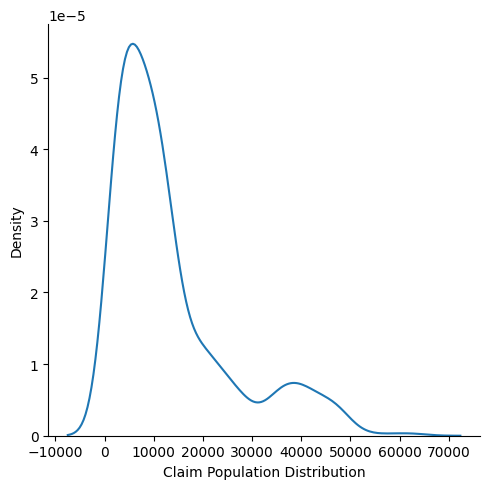

In [ ]:
sns.displot(data=df,x= 'claim',kind='kde')
plt.xlabel('Claim Population Distribution')

In [ ]:
# Seems like lognormal/pareto distribution

In [ ]:
# Lets take 100 sample of size 30

In [ ]:
samples = []
for i in range(10000):
  samples.append((df['claim'].sample(50).tolist()))


In [ ]:
#Calculate means of the samples
sample_mean = np.mean(samples,axis=1)

Text(0.5, 9.444444444444438, 'Claim Sample mean')

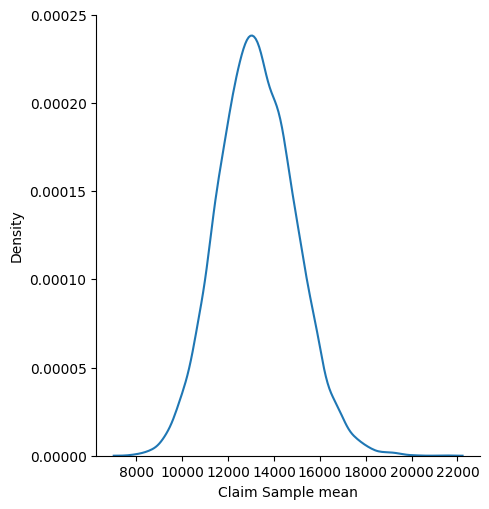

In [ ]:
sns.displot(data=sample_mean,kind='kde')
plt.xlabel('Claim Sample mean')


In [ ]:
#For Central Limit Theorem to Hold:
# 1. Sample mean should be close to Population mean.
# 2. Variance of Sample Means should be close to Population Variance / Sample Size.

population_mean = df['claim'].mean()
population_var = df['claim'].var()

Empirical_mean = sample_mean.mean()
Empirical_var = sample_mean.var()

theoretical_variance_of_samples = population_var /50

print(f'Population mean = {population_mean:.2f}')
print(f'Empirical mean = {Empirical_mean:.2f}')
print(f'\n')
print(f'Population Var = {population_var:.2f}')
print(f'Thoeritical sample variance = {theoretical_variance_of_samples:.2f}')
print(f'Empirical sample variance = {Empirical_var:.2f}')


Population mean = 13252.75
Empirical mean = 13250.17


Population Var = 146642637.11
Thoeritical sample variance = 2932852.74
Empirical sample variance = 2778014.10


Hypothesis Testing (Z-test)

In [ ]:
from scipy import stats

# Here, we take the Age column
# Let's assume a known population mean age of 35 years (e.g., from a national average).
# H0: The mean age of policyholders in this dataset is equal to 35 years (μ = 35).
# H1: The mean age of policyholders in this dataset is not equal to 35 years (μ ≠ 35).

# Hypothesiesd_mean = 35 , alpha = 0.05
Hypo_mean = 35 ; alpha = 0.05
# 1. Let's take a sample from data.
age_sample = df['age'].dropna().sample(50)

#2. Let's calculate sample mean and sample std
age_mean_sample = age_sample.mean()
age_std_sample = age_sample.std()

#3. Calculate z-statistic
z = (age_mean_sample - Hypo_mean)/((df['age'].std())/np.sqrt(50))

#4. Calculate P-value
p_value = 2 * stats.norm.sf(abs(z))

if p_value > alpha:
  print(f'P_value: {p_value}')
  print(f'Since p_value({p_value}) > alpha(0.05) therefore we do not have enough evidence to reject the null hypothesis')
else:
  print(f'P_value: {p_value}')
  print(f'Since p_value({p_value}) < alpha(0.05) therefore we can reject the null hypothesis')

P_value: 0.00031256420560297603
Since p_value(0.00031256420560297603) < alpha(0.05) therefore we can reject the null hypothesis


Hypothesis Test (T-test)

In [ ]:
# Single-sample t-test
# Null Hypothesis (H0): The mean BMI of policyholders is equal to 25 kg/m² (μ = 25).
# Alternative Hypothesis (H1): The mean BMI of policyholders is not equal to 25 kg/m² (μ ≠ 25).

# Hypo_mean_t = 25, alpha = 0.05, n = 50
Hypo_mean_t = 25; alpha = 0.05; n = 50

#1. First let's take a random sample of bmi's from data
sample_bmi = np.asarray(df['bmi'].sample(50).tolist())

#2. Calculate sample_mean, sample_std
sample_bmi_mean = sample_bmi.mean()
sample_bmi_std = sample_bmi.std()

#3. As we don't have pop std, we use sample std and calculate t-statistic
t_score = (sample_bmi_mean - Hypo_mean_t)/(sample_bmi_std/(np.sqrt(n)))

#4. Calculate the p value
p_value_ttest = 2 * stats.t.sf(49,abs(t_score))

### This can also be done easily using scipy = 't_statistic_1samp, p_value_1samp = stats.ttest_1samp(sample_bmi, Hypo_mean_t)'

#5. Compare with alpha and draw conclusion
if p_value_ttest > alpha:
  print(f'P_value: {p_value_ttest}')
  print(f'Since p_value({p_value_ttest}) > alpha(0.05) therefore we do not have enough evidence to reject the null hypothesis')
else:
  print(f'P_value: {p_value_ttest}')
  print(f'Since p_value({p_value_ttest}) < alpha(0.05) therefore we can reject the null hypothesis')

P_value: 4.1834907742199206e-11
Since p_value(4.1834907742199206e-11) < alpha(0.05) therefore we can reject the null hypothesis


In [ ]:
# Independent two sample test
# Null Hypothesis (H0): The mean claim amount for male policyholders is equal to the mean claim amount for female policyholders (μ_male = μ_female).
# The mean claim amount for male policyholders is not equal to the mean claim amount for female policyholders (μ_male ≠ μ_female).

13919.790457227142
12569.578897280968


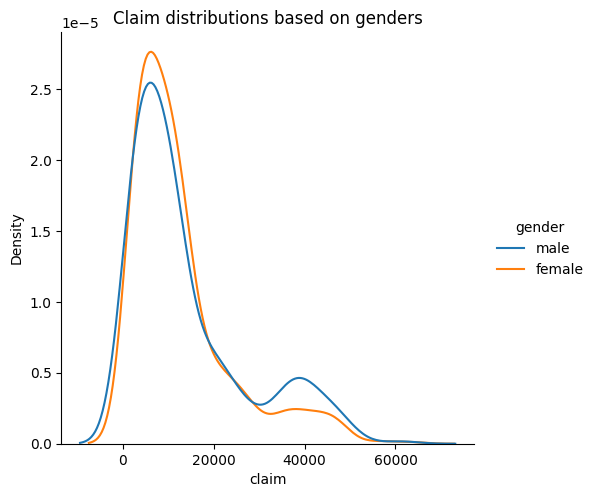

In [ ]:
#Lets investigate the distributions of female and males

sns.displot(data=df,x='claim',kind='kde',hue=df['gender'])
plt.title('Claim distributions based on genders')

print(df[df['gender'] == 'male']['claim'].mean())
print(df[df['gender'] == 'female']['claim'].mean())

In [ ]:
#1. Lets draw male and female samples
male_claim_sample = df[df['gender'] == 'male']['claim'].sample(50)
female_claim_sample = df[df['gender'] == 'female']['claim'].sample(50)

#2. Since our sample size > 30 therefore we can assume norma;lity, but we have to check for equality of variances using levene test

from scipy.stats import levene

levene_test = levene(male_claim_sample,female_claim_sample)
print(levene_test) # Since pvalue > alpha(0.05) therefore we variances are equal


#3. Calculate sample means and stds
male_mean = male_claim_sample.mean()
female_mean = female_claim_sample.mean()

male_std = male_claim_sample.std()
female_std = female_claim_sample.std()



#4. Calculate t_statistic and p_value

t_score_ttest_two_ind_sample, p_value_ttest_two_ind_sample = stats.ttest_ind(male_claim_sample, female_claim_sample, equal_var=True)


#5. Compare with alpha and draw conclusion
if p_value_ttest_two_ind_sample > alpha:
  print(f'P_value: {p_value_ttest_two_ind_sample}')
  print(f'Since p_value({p_value_ttest_two_ind_sample}) > alpha(0.05) therefore we do not have enough evidence to reject the null hypothesis')
else:
  print(f'P_value: {p_value_ttest_two_ind_sample}')
  print(f'Since p_value({p_value_ttest_two_ind_sample}) < alpha(0.05) therefore we can reject the null hypothesis')

LeveneResult(statistic=np.float64(0.3120854677330048), pvalue=np.float64(0.5776775163930952))
P_value: 0.4675777573849317
Since p_value(0.4675777573849317) > alpha(0.05) therefore we do not have enough evidence to reject the null hypothesis


In [ ]:
#---------------2 dependent t-test not applicable on the dataset -----------------------------------------------

Hypothesis Test (Chi Square Test)

In [ ]:
# Goodness of Fit test
# Null Hypothesis (H0): Gender distribution follows uniform distribution
# ALternative Hypothesis(Ha): It does not follow unfirom distribution

In [ ]:
#Lets investigate the gender column
df['gender'].value_counts() ## There are approx equal males and femals (follows unform distribution)

,count
gender,
male,678
female,662


Text(0, 0.5, 'Count of people')

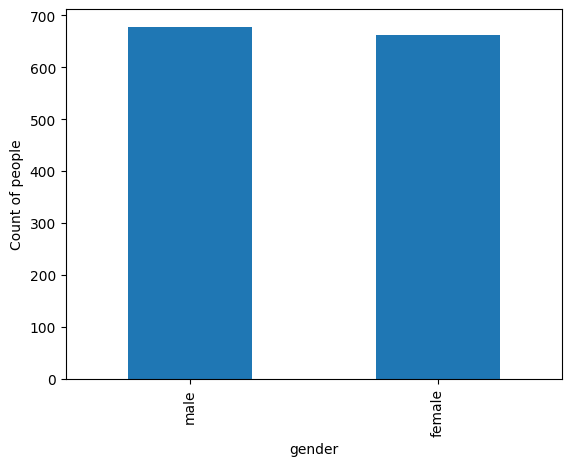

In [ ]:
df['gender'].value_counts().plot(kind='bar')
plt.ylabel('Count of people')

In [ ]:
#check for missing values
df['gender'].isnull().sum()

np.int64(0)

In [ ]:
#1. Set up the observed table
observed_table = df['gender'].value_counts()

In [ ]:
#2. Set up expected table
## For uniform distribution (1340 * 0.5 = 670 males and females)
expected_male_freq =  670
expected_female_freq = 670

In [ ]:
#3. Calculate squared diff
male_diff = (observed_table['male'] - expected_male_freq) ** 2
female_diff = (observed_table['female'] - expected_male_freq) ** 2


In [ ]:
#4. Calculate chi-statistic and degree of freedom
chi_score = (male_diff/expected_male_freq) + (female_diff/expected_female_freq)
dof = len(observed_table) - 1 #Should be 1 as there are only two categories

In [ ]:
#5. calculate the p_value
p_value_chi = 1 - stats.chi2.cdf(chi_score,dof)

#### This whole thing could also be done easily using the stats.chisquare function scipy
##ex_array = [expected_male_freq,expected_female_freq]
##stats.chisquare(f_obs=observed_table,f_exp=ex_array)

In [ ]:
#6. Now compare with alpha and draw conclusions
if p_value_chi  > alpha:
  print(f'P_value: {p_value_chi }')
  print(f'Since p_value({p_value_chi }) > alpha(0.05) therefore we do not have enough evidence to reject the null hypothesis')
else:
  print(f'P_value: {p_value_chi }')
  print(f'Since p_value({p_value_chi }) < alpha(0.05) therefore we can reject the null hypothesis')

P_value: 0.6620484783519132
Since p_value(0.6620484783519132) > alpha(0.05) therefore we do not have enough evidence to reject the null hypothesis


In [ ]:
#Test for independence
#H0 (Null Hypothesis) : There is no association between gender and region
#Ha (Alternate Hypothesis): There is an association/correlation between gender and region

In [ ]:
#1. Lets start with setting up a contigency table between gender and region (OBSERVED)

observed_frequency = pd.crosstab(columns= df['region'],index = df['gender']).to_numpy()


In [ ]:
#2. Call the chi2_contigency table in scipy to get the chi_stat and p_value
chi2_stat, p_value_contingency, dof, expected = stats.chi2_contingency(observed_frequency)


In [ ]:
#3. Now compare with alpha and draw conclusions
if p_value_contingency  > alpha:
  print(f'P_value: {p_value_contingency }')
  print(f'Since p_value({p_value_contingency }) > alpha(0.05) therefore we do not have enough evidence to reject the null hypothesis')
else:
  print(f'P_value: {p_value_contingency }')
  print(f'Since p_value({p_value_contingency }) < alpha(0.05) therefore we can reject the null hypothesis')

P_value: 0.6315234955336224
Since p_value(0.6315234955336224) > alpha(0.05) therefore we do not have enough evidence to reject the null hypothesis


'southeast'

In [ ]:
#ANOVA test(one-way)
#Null Hypothesis (H0): The mean claim amount is the same across all regions (e.g., mean claim in 'southeast' = mean claim in 'northwest' = mean claim in 'southwest' = mean claim in 'northeast').
#Alternate Hypothesis (Ha): At least one region has a different mean claim amount from the others.


mode = df['region'].mode()[0]
df['region'].fillna(mode,inplace = True)
df['region'].isnull().sum()


/tmp/ipykernel_9234/1174405860.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['region'].fillna(mode,inplace = True)


np.int64(0)

Text(0, 0.5, 'Claim amouhts')

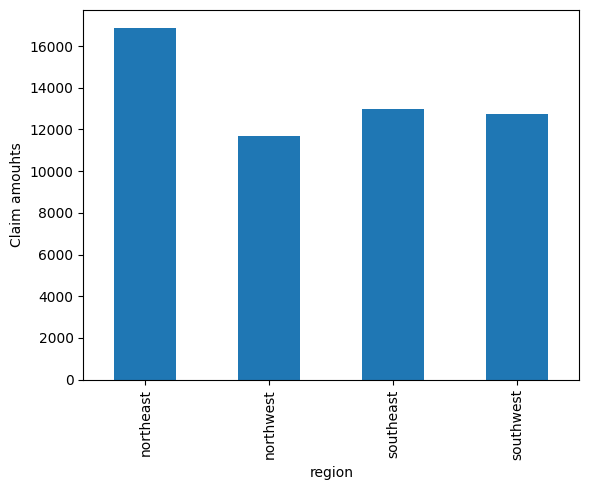

In [ ]:
#Let's investigate claim amounts depending on regions
df['claim'].groupby(df['region']).mean().plot(kind='bar')
plt.ylabel('Claim amouhts')

#We can clearly see that means claims of each of the regions are different (especially the northeast which is the main culprit: it has the highest mean claim )

In [ ]:
#1. Lets first get claim amounts for each region

northeast_claim = df[df['region'] == 'northeast']['claim']
northwestt_claim = df[df['region'] == 'northwest']['claim']
southeast_claim = df[df['region'] == 'southeast']['claim']
southwest_claim = df[df['region'] == 'southwest']['claim']

In [ ]:
#2. Use scipy to perform one_way ANOVA
f_statistic, p_value_anova = stats.f_oneway(northeast_claim,northwestt_claim,southeast_claim,southwest_claim)


#3. Now compare with alpha and draw conclusions
if p_value_anova  > alpha:
  print(f'P_value: {p_value_anova }')
  print(f'Since p_value({p_value_anova }) > alpha(0.05) therefore we do not have enough evidence to reject the null hypothesis')
else:
  print(f'P_value: {p_value_anova }')
  print(f'Since p_value({p_value_anova }) < alpha(0.05) therefore we can reject the null hypothesis')

P_value: 3.923910319360799e-06
Since p_value(3.923910319360799e-06) < alpha(0.05) therefore we can reject the null hypothesis


In [ ]:
#Now lets conduct post-hoc test to find the culprit for this result


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd



# Perform Tukey's HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=df['claim'], groups=df['region'], alpha=alpha)

print(tukey_result)

#We can conclude that northeast is the main culprit.

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
  group1    group2   meandiff  p-adj    lower      upper    reject
------------------------------------------------------------------
northeast northwest -5216.9563    0.0 -7834.5686 -2599.3439   True
northeast southeast -3909.9232 0.0004 -6411.5986 -1408.2479   True
northeast southwest -4165.9149 0.0004 -6840.9992 -1490.8306   True
northwest southeast   1307.033 0.4231  -898.4994  3512.5655  False
northwest southwest  1051.0414 0.6733 -1349.3898  3451.4726  False
southeast southwest  -255.9917 0.9915 -2529.4373   2017.454  False
------------------------------------------------------------------
